<a href="https://colab.research.google.com/github/hasinduW/SE4050-waste-classification-4models/blob/feature%2Fleader-cnn-aug-mobilenetv2/DL_Waste_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
import os
# Remove any existing files in the mountpoint directory
if os.path.exists('/content/drive'):
  !rm -rf /content/drive/*
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     GlobalAveragePooling2D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
tf.__version__

'2.19.0'

In [6]:
# STEP 1 — Paths & Config
DATA_DIR = '/content/drive/MyDrive/Waste_Images'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.20
EPOCHS     = 8          # keep 5–10 for fast runs
LR         = 1e-4
SEED       = 42
tf.keras.utils.set_random_seed(SEED)

assert os.path.isdir(DATA_DIR), f"Folder not found: {DATA_DIR}"


In [ ]:
# STEP 2 — Data Generators (Preprocess & Aug)
# a) Plain preprocessing (for Baseline)
base_gen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)

train_base = base_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, subset='training', seed=SEED)

val_base = base_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, subset='validation', seed=SEED)

# b) With augmentation (for Aug CNN & MobileNetV2)
aug_gen = ImageDataGenerator(
    rescale=1./255, validation_split=VAL_SPLIT,
    rotation_range=25, width_shift_range=0.2, height_shift_range=0.2,
    zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)

train_aug = aug_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, subset='training', seed=SEED)

val_aug = aug_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, subset='validation', seed=SEED)

class_names = list(train_base.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)


Found 6593 images belonging to 9 classes.
Found 1642 images belonging to 9 classes.
Found 6593 images belonging to 9 classes.
Found 1642 images belonging to 9 classes.
Classes: ['Aluminium', 'Carton', 'E-waste', 'Glass', 'Organic_Waste', 'Paper_and_Cardboard', 'Plastics', 'Textiles', 'Wood']


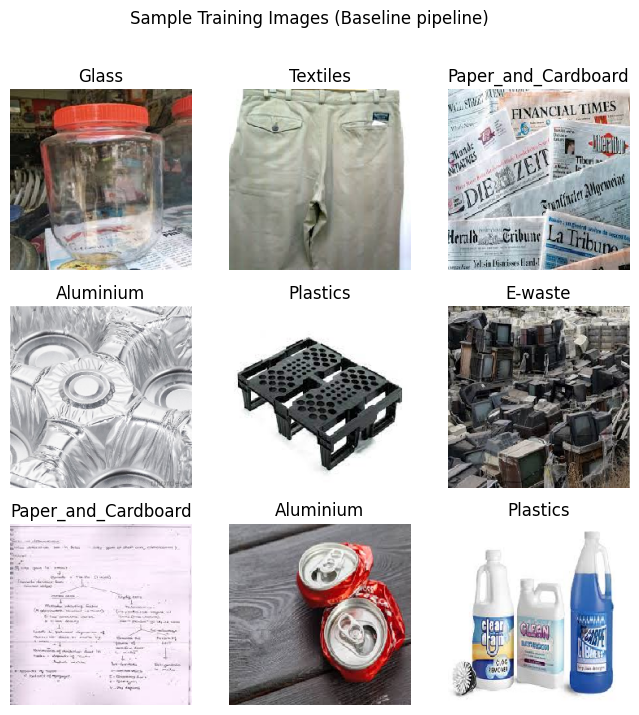

In [ ]:

# STEP 3 — Peek some training data
x_batch, y_batch = next(train_base)
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(class_names[np.argmax(y_batch[i])])
    plt.axis('off')
plt.suptitle("Sample Training Images (Baseline pipeline)")
plt.show()


In [ ]:
# Utilities — plotting & evaluation helpers
def plot_history(history, title=""):
    plt.figure(figsize=(12,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc'); plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.show()

def eval_and_report(model, val_gen, title=""):
    # Evaluate
    loss, acc = model.evaluate(val_gen, verbose=0)
    print(f"{title} — Val Accuracy: {acc*100:.2f}% | Val Loss: {loss:.4f}")
    # Predict
    preds = model.predict(val_gen, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = val_gen.classes
    # Confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7,6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    plt.title(f'Confusion Matrix — {title}')
    plt.show()
    # Classif report
    print(classification_report(true_labels, pred_labels, target_names=class_names))

In [ ]:
# STEP 4 — Callbacks (ES, LR scheduler, CKPT)

ckpt_dir = '/content/drive/MyDrive/Waste_Images/checkpoints'
os.makedirs(ckpt_dir, exist_ok=True)

def common_callbacks(tag):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(os.path.join(ckpt_dir, f'best_{tag}.keras'),
                        monitor='val_loss', save_best_only=True, verbose=1)
    ]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,985 (84.87 MB)

 Trainable params: 22,246,985 (84.87 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.2524 - loss: 2.0057 
Epoch 1: val_loss improved from inf to 1.77328, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_baseline_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 5205s 25s/step - accuracy: 0.2527 - loss: 2.0051 - val_accuracy: 0.3459 - val_loss: 1.7733 - learning_rate: 1.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3899 - loss: 1.6986
Epoch 2: val_loss improved from 1.77328 to 1.69198, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_baseline_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 931s 4s/step - accuracy: 0.3899 - loss: 1.6985 - val_accuracy: 0.3892 - val_loss: 1.6920 - learning_rate: 1.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4483 - loss: 1.5576
Epoch 3: val_loss improved from 1.69198 to 1.64575, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_baseline_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 927s 4s

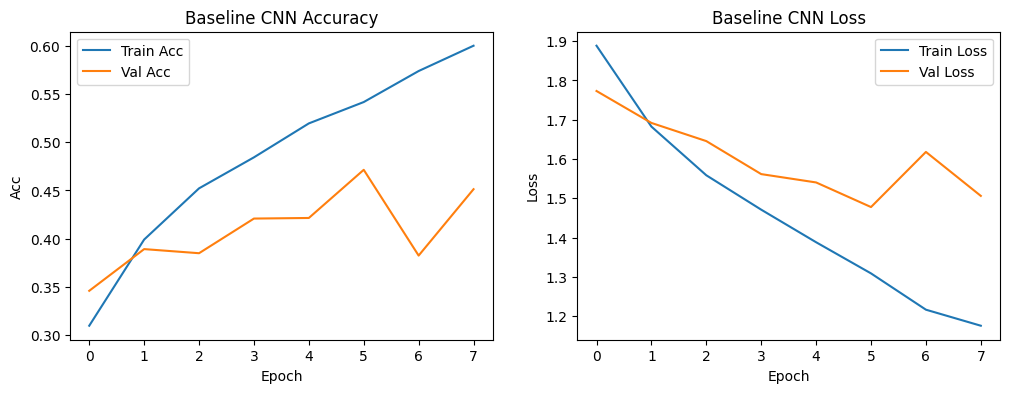

Baseline CNN — Val Accuracy: 47.14% | Val Loss: 1.4779


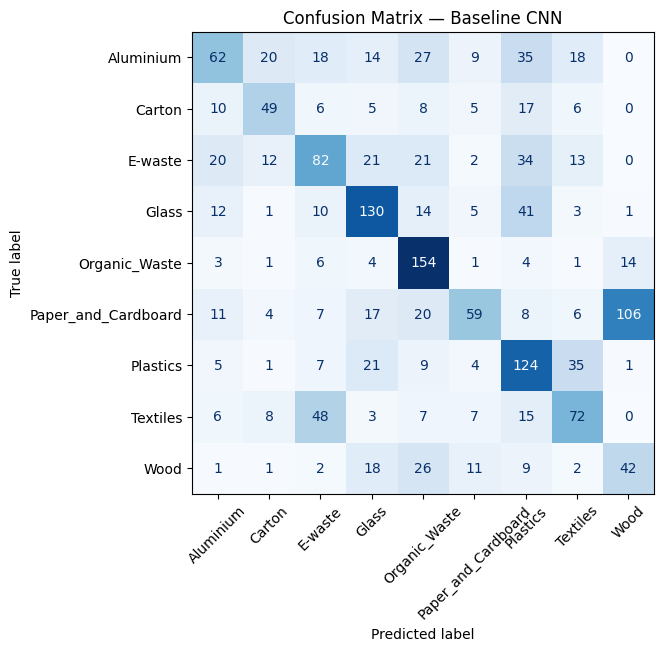

                     precision    recall  f1-score   support

          Aluminium       0.48      0.31      0.37       203
             Carton       0.51      0.46      0.48       106
            E-waste       0.44      0.40      0.42       205
              Glass       0.56      0.60      0.58       217
      Organic_Waste       0.54      0.82      0.65       188
Paper_and_Cardboard       0.57      0.25      0.35       238
           Plastics       0.43      0.60      0.50       207
           Textiles       0.46      0.43      0.45       166
               Wood       0.26      0.38      0.30       112

           accuracy                           0.47      1642
          macro avg       0.47      0.47      0.46      1642
       weighted avg       0.48      0.47      0.46      1642



In [ ]:
# STEP 5 — Model 1: Baseline CNN (from scratch)
def build_baseline_cnn(input_shape=(224,224,3), classes=9):
    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
        MaxPooling2D(2,2),
        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(LR), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

baseline = build_baseline_cnn(classes=num_classes)
baseline.summary()

hist_base = baseline.fit(
    train_base, epochs=EPOCHS, validation_data=val_base,
    callbacks=common_callbacks('baseline_cnn'), verbose=1
)
plot_history(hist_base, "Baseline CNN")
eval_and_report(baseline, val_base, "Baseline CNN")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2307 - loss: 2.0516
Epoch 1: val_loss improved from inf to 1.84439, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_aug_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 1093s 5s/step - accuracy: 0.2309 - loss: 2.0511 - val_accuracy: 0.3252 - val_loss: 1.8444 - learning_rate: 1.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3351 - loss: 1.8221
Epoch 2: val_loss improved from 1.84439 to 1.76955, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_aug_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 1101s 5s/step - accuracy: 0.3351 - loss: 1.8220 - val_accuracy: 0.3484 - val_loss: 1.7696 - learning_rate: 1.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3648 - loss: 1.7578
Epoch 3: val_loss improved from 1.76955 to 1.71852, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_aug_cnn.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 1048s 5s/step - accuracy

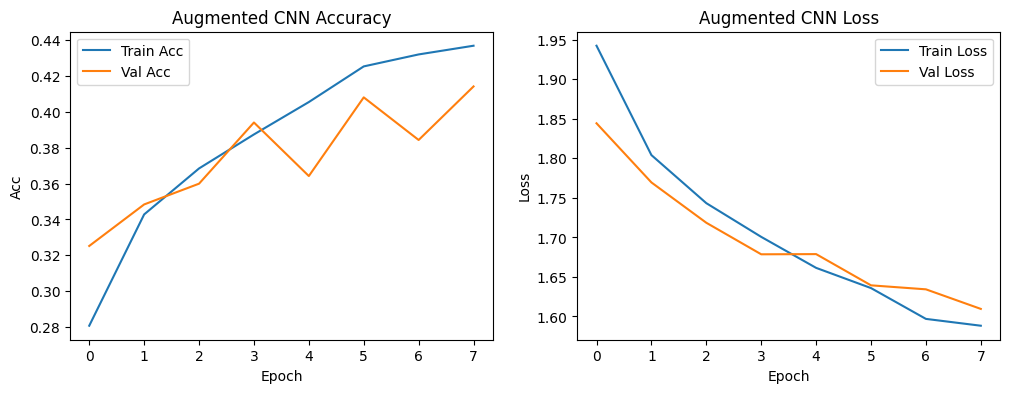

Augmented CNN — Val Accuracy: 40.32% | Val Loss: 1.6148


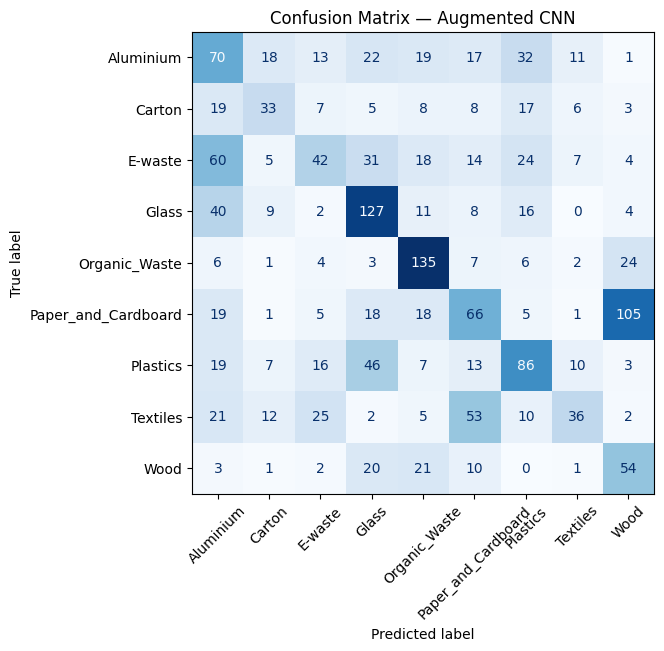

                     precision    recall  f1-score   support

          Aluminium       0.27      0.34      0.30       203
             Carton       0.38      0.31      0.34       106
            E-waste       0.36      0.20      0.26       205
              Glass       0.46      0.59      0.52       217
      Organic_Waste       0.56      0.72      0.63       188
Paper_and_Cardboard       0.34      0.28      0.30       238
           Plastics       0.44      0.42      0.43       207
           Textiles       0.49      0.22      0.30       166
               Wood       0.27      0.48      0.35       112

           accuracy                           0.40      1642
          macro avg       0.40      0.40      0.38      1642
       weighted avg       0.40      0.40      0.38      1642



In [ ]:
# STEP 6 — Model 2: CNN with Data Augmentation




aug_cnn = build_baseline_cnn(classes=num_classes)
hist_aug = aug_cnn.fit(
    train_aug, epochs=EPOCHS, validation_data=val_aug,
    callbacks=common_callbacks('aug_cnn'), verbose=1
)
plot_history(hist_aug, "Augmented CNN")
eval_and_report(aug_cnn, val_aug, "Augmented CNN")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3145 - loss: 2.0376
Epoch 1: val_loss improved from inf to 1.00580, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 521s 2s/step - accuracy: 0.3152 - loss: 2.0355 - val_accuracy: 0.7010 - val_loss: 1.0058 - learning_rate: 1.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6638 - loss: 0.9934
Epoch 2: val_loss improved from 1.00580 to 0.77814, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 510s 2s/step - accuracy: 0.6639 - loss: 0.9930 - val_accuracy: 0.7473 - val_loss: 0.7781 - learning_rate: 1.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7458 - loss: 0.7621
Epoch 3: val_loss improved from 0.77814 to 0.70761, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 516s 2s/step -

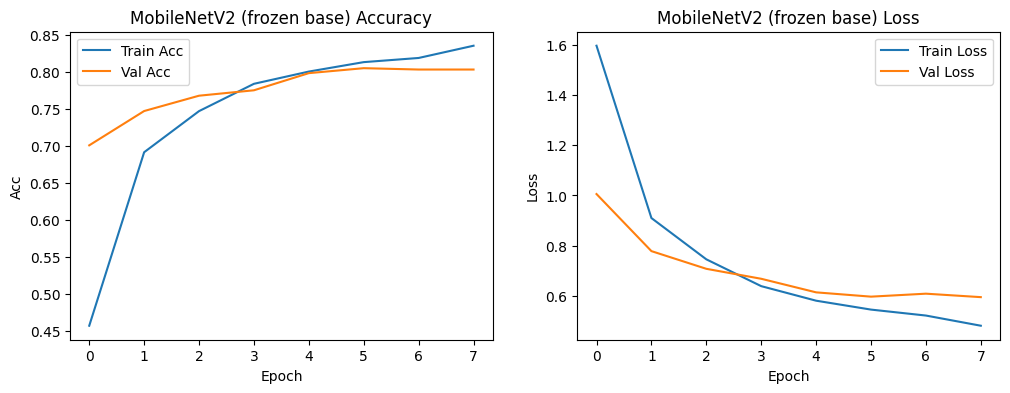

MobileNetV2 — Val Accuracy: 79.66% | Val Loss: 0.6129


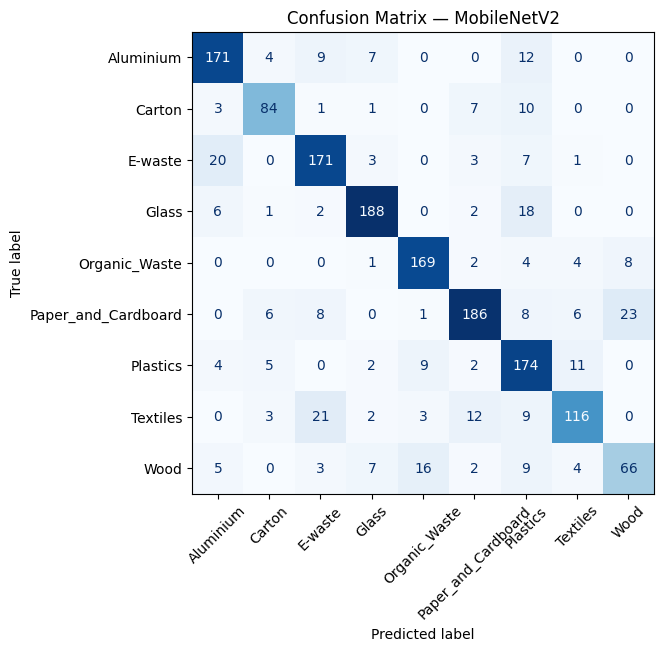

                     precision    recall  f1-score   support

          Aluminium       0.82      0.84      0.83       203
             Carton       0.82      0.79      0.80       106
            E-waste       0.80      0.83      0.81       205
              Glass       0.89      0.87      0.88       217
      Organic_Waste       0.85      0.90      0.88       188
Paper_and_Cardboard       0.86      0.78      0.82       238
           Plastics       0.69      0.84      0.76       207
           Textiles       0.82      0.70      0.75       166
               Wood       0.68      0.59      0.63       112

           accuracy                           0.81      1642
          macro avg       0.80      0.79      0.80      1642
       weighted avg       0.81      0.81      0.81      1642



In [ ]:
# STEP 7 — Model 3: Transfer Learning (MobileNetV2)
base_mnet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
for layer in base_mnet.layers:
    layer.trainable = False  # freeze base for fast, stable training

mnet = Sequential([
    base_mnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
mnet.compile(optimizer=Adam(LR), loss='categorical_crossentropy', metrics=['accuracy'])
mnet.summary()

hist_mnet = mnet.fit(
    train_aug, epochs=EPOCHS, validation_data=val_aug,
    callbacks=common_callbacks('mobilenetv2'), verbose=1
)
plot_history(hist_mnet, "MobileNetV2 (frozen base)")
eval_and_report(mnet, val_aug, "MobileNetV2")


Epoch 1/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7176 - loss: 0.8438
Epoch 1: val_loss improved from inf to 0.66479, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2_finetune.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 658s 3s/step - accuracy: 0.7178 - loss: 0.8432 - val_accuracy: 0.7868 - val_loss: 0.6648 - learning_rate: 1.0000e-05
Epoch 2/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7995 - loss: 0.5980
Epoch 2: val_loss improved from 0.66479 to 0.62068, saving model to /content/drive/MyDrive/Waste_Images/checkpoints/best_mobilenetv2_finetune.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 598s 3s/step - accuracy: 0.7996 - loss: 0.5979 - val_accuracy: 0.7990 - val_loss: 0.6207 - learning_rate: 1.0000e-05
Epoch 3/3
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8155 - loss: 0.5493
Epoch 3: val_loss did not improve from 0.62068
207/207 ━━━━━━━━━━━━━━━━━━━━ 592s 3s/step - accuracy: 0.8155 - loss: 0.5491 - val_accuracy: 0.7917 - val_loss: 0.6316

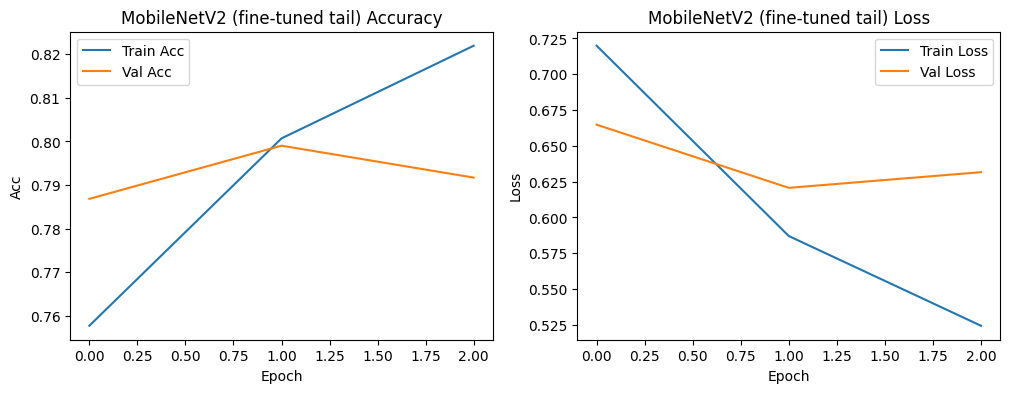

MobileNetV2 (fine-tuned) — Val Accuracy: 78.44% | Val Loss: 0.6428


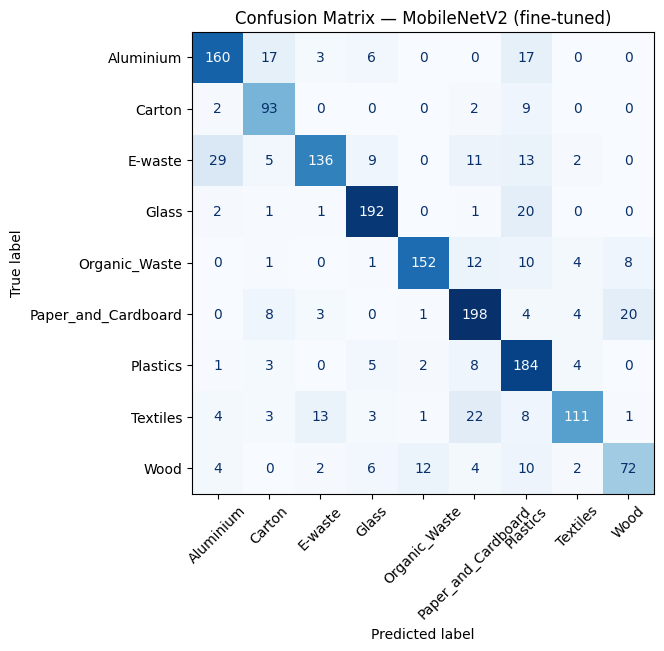

                     precision    recall  f1-score   support

          Aluminium       0.79      0.79      0.79       203
             Carton       0.71      0.88      0.78       106
            E-waste       0.86      0.66      0.75       205
              Glass       0.86      0.88      0.87       217
      Organic_Waste       0.90      0.81      0.85       188
Paper_and_Cardboard       0.77      0.83      0.80       238
           Plastics       0.67      0.89      0.76       207
           Textiles       0.87      0.67      0.76       166
               Wood       0.71      0.64      0.68       112

           accuracy                           0.79      1642
          macro avg       0.80      0.78      0.78      1642
       weighted avg       0.80      0.79      0.79      1642



In [ ]:
# STEP 8 — (Optional) Fine-tune MobileNetV2 last blocks
# Unfreeze last N layers for a short fine-tune if you have time/GPU.
UNFREEZE_LAST = 20  # tune this if needed; keep small for 3-day plan

for layer in base_mnet.layers[-UNFREEZE_LAST:]:
    layer.trainable = True

mnet.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
hist_ft = mnet.fit(
    train_aug, epochs=3, validation_data=val_aug,
    callbacks=common_callbacks('mobilenetv2_finetune'), verbose=1
)
plot_history(hist_ft, "MobileNetV2 (fine-tuned tail)")
eval_and_report(mnet, val_aug, "MobileNetV2 (fine-tuned)")

In [ ]:
# STEP 9 — Save all models for team compare
save_root = '/content/drive/MyDrive/Waste_Images'
baseline.save(os.path.join(save_root, 'model_baseline_cnn.keras'))
aug_cnn.save(os.path.join(save_root, 'model_augmented_cnn.keras'))
mnet.save(os.path.join(save_root, 'model_mobilenetv2.keras'))
print("✅ Saved: baseline, augmented CNN, and MobileNetV2 to Drive.")

✅ Saved: baseline, augmented CNN, and MobileNetV2 to Drive.


In [ ]:

# STEP 10 — Quick comparison table (val acc)
def best_val_acc(h):  # grab best validation accuracy recorded
    return float(np.max(h.history['val_accuracy']))

summary = {
    "Baseline CNN": best_val_acc(hist_base),
    "Augmented CNN": best_val_acc(hist_aug),
    "MobileNetV2 (frozen)": best_val_acc(hist_mnet),
    "MobileNetV2 (fine-tuned)": best_val_acc(hist_ft) if 'hist_ft' in globals() else None
}
summary


{'Baseline CNN': 0.47137635946273804,
 'Augmented CNN': 0.4141291081905365,
 'MobileNetV2 (frozen)': 0.8051156997680664,
 'MobileNetV2 (fine-tuned)': 0.7990255951881409}

In [22]:
import os, glob
subs = [d for d in sorted(os.listdir(DATA_DIR)) if os.path.isdir(os.path.join(DATA_DIR, d))]
print("Subfolders under DATA_DIR:", subs)
for d in subs[:20]:
    n = len(glob.glob(os.path.join(DATA_DIR, d, "*.*")))
    print(f"{d:25s} -> {n} files")


Subfolders under DATA_DIR: []


Moving checkpoints from /content/drive/MyDrive/Waste_Images/checkpoints to /content/drive/MyDrive/waste_ckpts
Removed empty directory: /content/drive/MyDrive/Waste_Images/checkpoints
✅ Checkpoints moved.
✅ Data directory found at /content/drive/MyDrive/Waste_Images.
Found 6593 images belonging to 9 classes.
Found 1642 images belonging to 9 classes.
✅ Classes: ['Aluminium', 'Carton', 'E-waste', 'Glass', 'Organic_Waste', 'Paper_and_Cardboard', 'Plastics', 'Textiles', 'Wood']
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,710,060 (17.97 MB)

 Trainable params: 660,489 (2.52 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


🚀 Training EfficientNetB0 (frozen base)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5019 - loss: 1.5277
Epoch 1: val_loss improved from inf to 0.60335, saving model to /content/drive/MyDrive/waste_ckpts/best_efficientnetb0.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 2078s 10s/step - accuracy: 0.5027 - loss: 1.5257 - val_accuracy: 0.8557 - val_loss: 0.6033 - learning_rate: 1.0000e-04
Epoch 2/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8395 - loss: 0.5470
Epoch 2: val_loss improved from 0.60335 to 0.43389, saving model to /content/drive/MyDrive/waste_ckpts/best_efficientnetb0.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 723s 3s/step - accuracy: 0.8395 - loss: 0.5468 - val_accuracy: 0.8739 - val_loss: 0.4339 - learning_rate: 1.0000e-04
Epoch 3/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8732 - loss: 0.4064
Epoch 3: val_loss improved from 0.43389 to 0.39073, saving model to /content/drive/MyDrive/waste_ckpts/best_efficientnetb0.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 738s 4s/step - accuracy: 0.8732 - loss: 0.

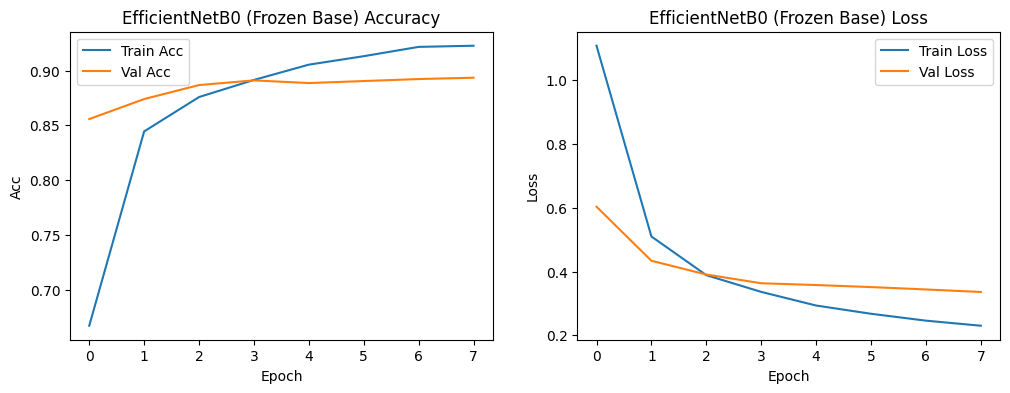

EfficientNetB0 (frozen) — Val Accuracy: 89.34% | Val Loss: 0.3360


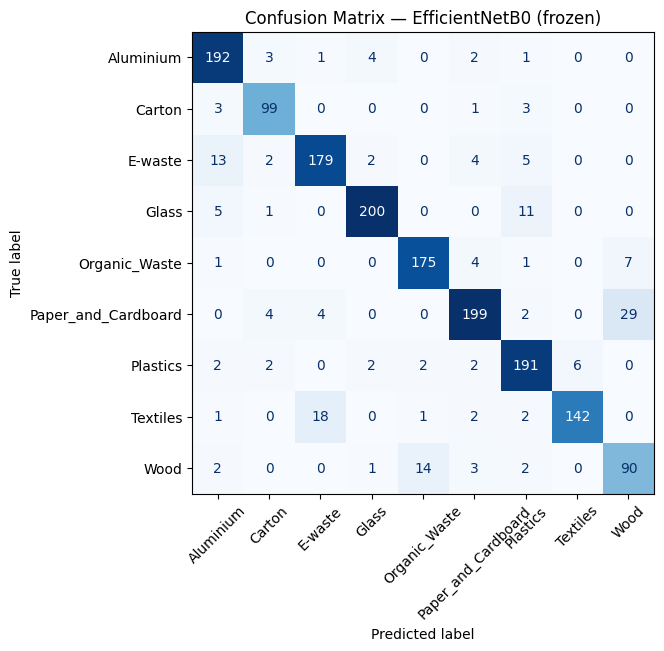

                     precision    recall  f1-score   support

          Aluminium       0.88      0.95      0.91       203
             Carton       0.89      0.93      0.91       106
            E-waste       0.89      0.87      0.88       205
              Glass       0.96      0.92      0.94       217
      Organic_Waste       0.91      0.93      0.92       188
Paper_and_Cardboard       0.92      0.84      0.87       238
           Plastics       0.88      0.92      0.90       207
           Textiles       0.96      0.86      0.90       166
               Wood       0.71      0.80      0.76       112

           accuracy                           0.89      1642
          macro avg       0.89      0.89      0.89      1642
       weighted avg       0.90      0.89      0.89      1642


🔧 Fine-tuning top EfficientNetB0 layers...
Epoch 1/8
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8207 - loss: 0.5701
Epoch 1: val_loss improved from inf to 0.42493, saving model to /content/dri

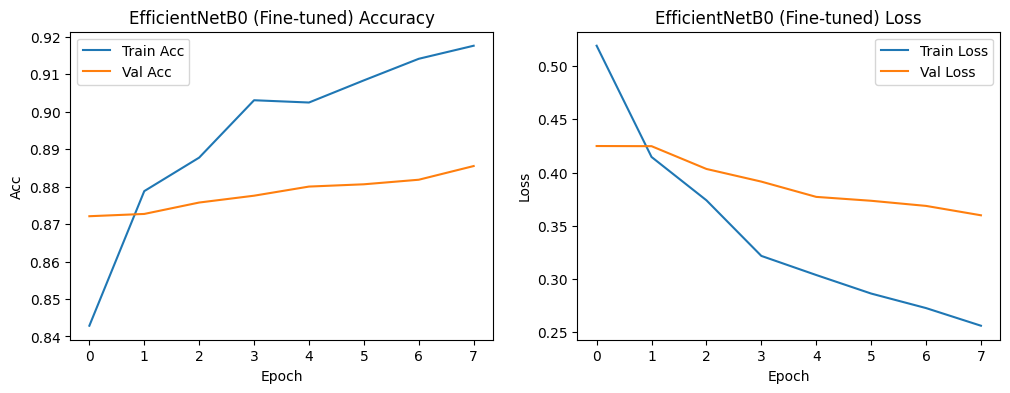

EfficientNetB0 (Fine-tuned) — Val Accuracy: 88.55% | Val Loss: 0.3598


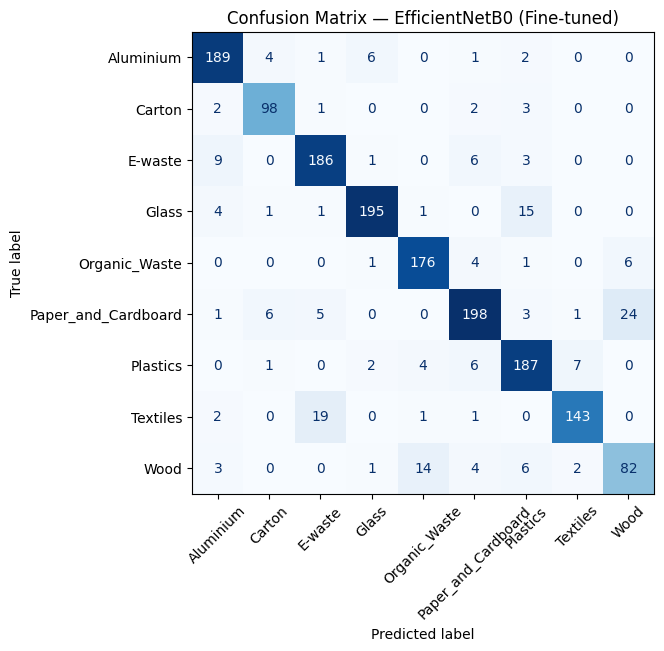

                     precision    recall  f1-score   support

          Aluminium       0.90      0.93      0.92       203
             Carton       0.89      0.92      0.91       106
            E-waste       0.87      0.91      0.89       205
              Glass       0.95      0.90      0.92       217
      Organic_Waste       0.90      0.94      0.92       188
Paper_and_Cardboard       0.89      0.83      0.86       238
           Plastics       0.85      0.90      0.88       207
           Textiles       0.93      0.86      0.90       166
               Wood       0.73      0.73      0.73       112

           accuracy                           0.89      1642
          macro avg       0.88      0.88      0.88      1642
       weighted avg       0.89      0.89      0.89      1642

✅ Saved EfficientNetB0 model to Drive.

📊 Summary (with EfficientNetB0):
EfficientNetB0 (frozen)        -> 89.34%
EfficientNetB0 (fine-tuned)    -> 88.55%


In [7]:
# STEP 11 — EfficientNetB0 (Transfer Learning + Auto Path Fix + Fine-tuning)
from tensorflow.keras.applications import EfficientNetB0
import glob, shutil
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     GlobalAveragePooling2D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# --- Define Paths & Config (from SQs4IAVMQmij)
DATA_DIR = '/content/drive/MyDrive/Waste_Images'
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.20
EPOCHS     = 8
LR         = 1e-4
SEED       = 42
tf.keras.utils.set_random_seed(SEED)

# --- Move checkpoints OUT of the dataset root (so Keras won't treat it as a class) (from gK4ydNws73RY)
CKPT_DIR = '/content/drive/MyDrive/waste_ckpts'
os.makedirs(CKPT_DIR, exist_ok=True)
bad_ckpt = os.path.join(DATA_DIR, 'checkpoints')
if os.path.isdir(bad_ckpt):
    print(f"Moving checkpoints from {bad_ckpt} to {CKPT_DIR}")
    for f in os.listdir(bad_ckpt):
        src = os.path.join(bad_ckpt, f)
        dst = os.path.join(CKPT_DIR, f)
        try:
            shutil.move(src, dst)
        except Exception as e:
            print("Skip moving:", src, "->", e)
    try:
        os.rmdir(bad_ckpt)
        print(f"Removed empty directory: {bad_ckpt}")
    except OSError:
        pass
print("✅ Checkpoints moved.")

# --- Check if DATA_DIR exists before creating generators ---
if not os.path.exists(DATA_DIR):
    print(f"FATAL ERROR: Data directory not found at {DATA_DIR}. Please check the path and ensure Google Drive is mounted correctly.")
else:
    print(f"✅ Data directory found at {DATA_DIR}.")

    # --- Data Generators (Augmented) (from fvet1RfBfTNt, modified for EfficientNet preprocessing)
    aug_gen = ImageDataGenerator(
        preprocessing_function=tf.keras.applications.efficientnet.preprocess_input, # Use EfficientNet preprocessing
        validation_split=VAL_SPLIT,
        rotation_range=25, width_shift_range=0.2, height_shift_range=0.2,
        zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
    )

    val_gen = ImageDataGenerator(
        preprocessing_function=tf.keras.applications.efficientnet.preprocess_input, # Use EfficientNet preprocessing
        validation_split=VAL_SPLIT
    )

    train_aug = aug_gen.flow_from_directory(
        DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='training', shuffle=True, seed=SEED)

    val_aug = val_gen.flow_from_directory(
        DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='validation', shuffle=False, seed=SEED)

    class_names = list(train_aug.class_indices.keys())
    num_classes = len(class_names)
    print("✅ Classes:", class_names)

    # --- Callbacks (from uYFe-B4hf2e8)
    def common_callbacks(tag):
        return [
            EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
            ModelCheckpoint(os.path.join(CKPT_DIR, f'best_{tag}.keras'),
                            monitor='val_loss', save_best_only=True, verbose=1)
        ]

    # --- Utilities — plotting & evaluation helpers (from a3qNIr5QfsRp)
    def plot_history(history, title=""):
        plt.figure(figsize=(12,4))
        # Accuracy
        plt.subplot(1,2,1)
        plt.plot(history.history['accuracy'], label='Train Acc')
        plt.plot(history.history['val_accuracy'], label='Val Acc')
        plt.title(f'{title} Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc'); plt.legend()
        # Loss
        plt.subplot(1,2,2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title(f'{title} Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
        plt.show()

    def eval_and_report(model, val_gen, title=""):
        # Evaluate
        loss, acc = model.evaluate(val_gen, verbose=0)
        print(f"{title} — Val Accuracy: {acc*100:.2f}% | Val Loss: {loss:.4f}")
        # Predict
        preds = model.predict(val_gen, verbose=0)
        pred_labels = np.argmax(preds, axis=1)
        true_labels = val_gen.classes
        # Confusion matrix
        cm = confusion_matrix(true_labels, pred_labels)
        disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
        fig, ax = plt.subplots(figsize=(7,6))
        disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
        plt.title(f'Confusion Matrix — {title}')
        plt.show()
        # Classif report
        print(classification_report(true_labels, pred_labels, target_names=class_names))


    # --- Build EfficientNetB0 model
    base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
    for layer in base_eff.layers:
        layer.trainable = False  # freeze base initially

    eff_model = Sequential([
        base_eff,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

    eff_model.compile(optimizer=Adam(learning_rate=LR),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
    eff_model.summary()

    # --- Training (Stage 1: frozen base)
    print("\n🚀 Training EfficientNetB0 (frozen base)...")
    hist_eff = eff_model.fit(
        train_aug, epochs=EPOCHS, validation_data=val_aug,
        callbacks=common_callbacks('efficientnetb0'),
        verbose=1
    )
    plot_history(hist_eff, "EfficientNetB0 (Frozen Base)")
    eval_and_report(eff_model, val_aug, "EfficientNetB0 (frozen)")

    # --- Fine-tuning (Stage 2)
    print("\n🔧 Fine-tuning top EfficientNetB0 layers...")
    UNFREEZE_LAST = 50  # unfreeze last 50 layers for stronger learning
    for layer in base_eff.layers[-UNFREEZE_LAST:]:
        layer.trainable = True

    eff_model.compile(optimizer=Adam(learning_rate=1e-5),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

    hist_eff_ft = eff_model.fit(
        train_aug, epochs=8, validation_data=val_aug,
        callbacks=common_callbacks('efficientnetb0_finetune'),
        verbose=1
    )

    plot_history(hist_eff_ft, "EfficientNetB0 (Fine-tuned)")
    eval_and_report(eff_model, val_aug, "EfficientNetB0 (Fine-tuned)")

    # --- Save model
    save_root = '/content/drive/MyDrive/Waste_Images'
    eff_model.save(os.path.join(save_root, 'model_efficientnetb0.keras'))
    print("✅ Saved EfficientNetB0 model to Drive.")

    # --- Add to summary table (Assuming 'summary' dictionary exists from previous cells, otherwise initialize)
    if 'summary' not in globals():
        summary = {}

    def best_val_acc(h):  # grab best validation accuracy recorded
        return float(np.max(h.history['val_accuracy']))

    summary["EfficientNetB0 (frozen)"] = best_val_acc(hist_eff)
    summary["EfficientNetB0 (fine-tuned)"] = best_val_acc(hist_eff_ft) if 'hist_eff_ft' in locals() else None

    print("\n📊 Summary (with EfficientNetB0):")
    for k,v in summary.items():
        if v is not None:
            print(f"{k:30s} -> {v*100:.2f}%")
        else:
             print(f"{k:30s} -> N/A")